In [39]:
#import block
import pandas as pd
from keybert import KeyBERT
from collections import Counter

from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [40]:
#load model
model=KeyBERT()


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1092.88it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [41]:
def plot_pattern(dataframe,column,ngram_range=(2,3),top_phrase_per_plot=30,top_plots=5):
    """
    Detects plot patterns in genres and returns top_n phrases of length ngram range 
    returns dataframe with id,plotpoint and Count of frequency

    """
    # Add new column for Plot phrases to dataframe 
    dataframe['extracted_plotpoints'] = dataframe[column].apply( lambda x: [keyword[0] for keyword in model.extract_keywords(x,keyphrase_ngram_range=ngram_range,stop_words= 'english',top_n=top_phrase_per_plot)])
    
    all_plotpoints = []

    # put all keywords from a movie in a big list
    for plotlist in dataframe['extracted_plotpoints']:
        for plotpoint in plotlist:
            all_plotpoints.append(plotpoint)
   

    plot_points_count = Counter(all_plotpoints)

    plot_point_list = []
    # Create diconary with most common plot phrases and their count
    for phrase, count in plot_points_count.most_common(top_plots):
        plot_point_list.append({'Plotphrase': phrase, 'Count': count})


    plot_point_dataframe = pd.DataFrame(plot_point_list)

    return plot_point_dataframe

In [42]:
def wordmap(dataframe):
    frequency_dict = dataframe.set_index('Plotphrase')['Count'].to_dict()

    wordmap = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(frequency_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordmap, interpolation='bilinear')
    plt.axis('off')  
    plt.title("Wordmap for Genre Tropes")
    
    plt.show()
    

In [ ]:
def plotphrase_sucess(dataframe_plotphrases,dataframe_untouched,column_plotphrase, column_box_office):
    """
    Compares movies that use  common plotphrases sucess to movies that dont
    """
    dataframe_untouched = dataframe_untouched[dataframe_untouched[column_box_office]>0]


    list_plotphrase = list(dataframe_plotphrases['Plotphrase'])

    phrase_used_list =[]

    for movie_plotphrase in dataframe_untouched[column_plotphrase]:

        movie_uses_plotphrase = False

        for plotphrase in list_plotphrase:
            if plotphrase in movie_plotphrase:
                movie_uses_plotphrase = True
        
        phrase_used_list.append(movie_uses_plotphrase)
    
    dataframe_untouched['Used_Plotphrases'] = phrase_used_list
    
    succes= dataframe_untouched.groupby('Used_Plotphrases')[column_box_office].mean()
    succes_readable = succes.apply(lambda x: f"{x:,.0f} $")
    return succes_readable


                     Plotphrase  Count
0                 serial killer     23
1                   young woman     13
2                 group friends     10
3                 haunted house      9
4                      year old      7
5                 laurie strode      6
6               halloween night      6
7                      new home      6
8      paranormal investigators      5
9            demonic possession      5
10                michael myers      5
11                 raccoon city      5
12                  takes place      5
13                  horror film      5
14  paranormal investigators ed      4
15    investigators ed lorraine      4
16                twin brothers      4
17                house haunted      4
18                     new york      4
19               demonic entity      4


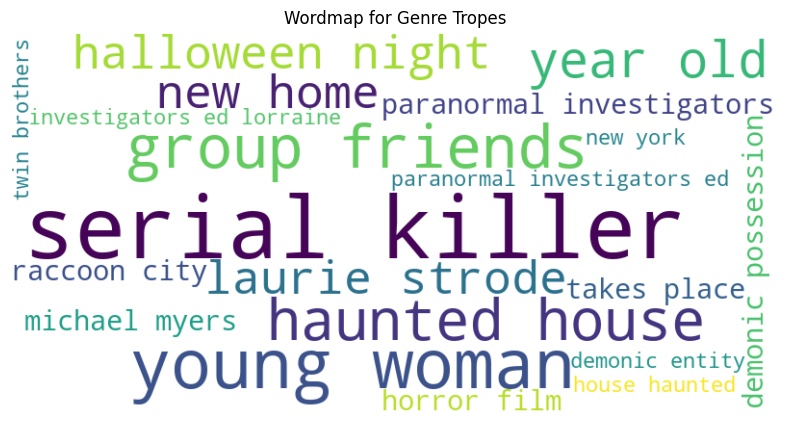

In [44]:
#testblock
data_test= pd.read_csv('movies_plot_horror.csv')
save_frame=(plot_pattern(data_test,'plot',top_plots=20))
print(save_frame)
wordmap(save_frame)



In [45]:
success_saved = plotphrase_sucess(save_frame,data_test,'plot','box_office_worldwide')
print(success_saved)

Used_Plotphrases
False    41,985,180 $
True     46,832,908 $
Name: box_office_worldwide, dtype: str


TODO:
Filter out names from Keybert
Filter same meaning eg. paranormal investigators ed // parnomal investigartor
Filter out horror film describing 